# Smile Detection Model Comparison using CNNs, Autoencoders and Classical Methods

`Author: Melanie Astrid Montaño Ramos`

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms
import numpy as np
from PIL import Image
import os # Gestión de la conexión código-sistema/ ejecuta código en la terminal
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [ ]:
!pip install deepspeed
import deepspeed
from deepspeed.profiling.flops_profiler import FlopsProfiler

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.0 MB/s eta 0:00:00
  Created wheel for deepspeed: filename=deepspeed-0.18.5-py3-none-any.whl size=1779278 sha256=f18f4b3fa55fbea9536cd8f36e425236124deac5a7640c9faed79979fc1a51c4
  Stored in directory: /root/.cache/pip/wheels/44/33/49/3e1af5a691f90c9acbec4ae97ff99d6b05f3cdf963fb12298f
Successfully built deepspeed
[2026-02-07 05:01:03,879] [WARNING] [real_accelerator.py:209:get_accelerator] Setting accelerator to CPU. If you have GPU or other accelerator, we were unable to detect it.


In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


In [ ]:
# importar acceso a google drive
from google.colab import drive
# drive.mount no monta carpetas en específico, sino la unidad completa
drive.mount('/content/drive')

Mounted at /content/drive


### Pipeline
archivo → PIL.Image → RGB → transform → Tensor → modelo

# Procesamiento

## Clase para creación del dataset

In [ ]:
class LFWDataset(Dataset):
    def __init__(
        self,
        faces_folder,
        smiling_labels_file,
        non_smiling_labels_file,
        transform= transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.ToTensor(), # Escala la imagen a [0.0, 1.0]
                                      transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)])): # usamos un array de [0.5,0.5,0.5] para normalizar cada canal de la imagen para que las entradas estén alineadas en 0

      self.faces_folder = faces_folder
      self.transform = transform

      self.smiling_labels_file = smiling_labels_file
      self.non_smiling_labels_file = non_smiling_labels_file


      # TODO: Read the smiling faces file and extract filenames
      # Hint: Open the file, read lines, strip whitespace, and replace .jpg with .ppm
      f = open(self.smiling_labels_file)
      smiling_files = f.read().replace('.jpg','.ppm').split('\n')
      f.close()

      smiling_files[:10] # type: list

      # TODO: Read the non-smiling faces file and extract filenames
      # Hint: Same process as above - open file, read lines, process filenames
      f = open(self.non_smiling_labels_file)
      non_smiling_files = f.read().replace('.jpg','.ppm').split('\n')
      f.close()

      # len(non_smiling_files) # type: list

      # Create image paths and labels
      self.image_paths = []
      self.labels = []
      self.targets = torch.tensor(self.labels)

      # TODO: Add smiling faces to the dataset with label = 1
      # Hint: Loop through smiling_files, create file path using os.path.join
      for file in smiling_files:
        file_path = os.path.join(self.faces_folder,file)
        os.path.isfile(file_path)

        if os.path.isfile(file_path):
          self.image_paths.append(file_path)
          self.labels.append(1)

      # TODO: Add non-smiling faces to the dataset with label = 0
      # Hint: Same process as above but with label = 0
      for file in non_smiling_files:
        file_path = os.path.join(self.faces_folder,file)

        if os.path.isfile(file_path):
          self.image_paths.append(file_path)
          self.labels.append(0)

      self.targets = torch.tensor(self.labels)


    def __len__(self):
  # TODO: Return the total number of images in the dataset
      return len(self.image_paths)

    def __getitem__(self, idx):
      # TODO: Get the image path and label for the given index
      # Hint: Use idx into your image_paths and labels lists
      image_path = self.image_paths[idx]
      label = self.labels[idx]

      # TODO: Load and convert the image to RGB
      image = Image.open(image_path).convert('RGB')
      # print(image.format, image.size, image.mode)
      # plt.imshow(image)
      # plt.axis("off")

      # Una vez normalizada de [-1,1] ya no se puede visualizar
      if self.transform:
        image = self.transform(image)

      return image, label

## Instanciación del dataset

In [ ]:
dataset = LFWDataset(
    faces_folder="/content/drive/MyDrive/Final_project/lfwcrop_color/lfwcrop_color/faces",
    smiling_labels_file="/content/drive/MyDrive/Final_project/SMILE_list.txt",
    non_smiling_labels_file="/content/drive/MyDrive/Final_project/NON-SMILE_list.txt"
)

img, label = dataset[11]
print(img.shape, label)

torch.Size([3, 64, 64]) 1


In [ ]:
(dataset.targets == 0).sum()

tensor(603)

## Splitting del dataset

In [ ]:
labels = dataset.targets

smile_idx = torch.where(labels == 1)[0]
nonsmile_idx = torch.where(labels == 0)[0]

torch.manual_seed(316)

smile_idx = smile_idx[torch.randperm(len(smile_idx))]
nonsmile_idx = nonsmile_idx[torch.randperm(len(nonsmile_idx))]

In [ ]:
# %%%%%%%% TRAINING SPLIT %%%%%%%%%%
# Autoencoder: 400 smiling
ae_smile_idx = smile_idx[:400]

# CNN/SVM: 200 smiling (subset de AE) + 200 non-smiling
cnn_svm_smile_idx = ae_smile_idx[:200]
cnn_svm_nonsmile_idx = nonsmile_idx[:200]

AEtrain_dataset = Subset(dataset, ae_smile_idx.tolist())
train_dataset = Subset(dataset,torch.cat([cnn_svm_smile_idx, cnn_svm_nonsmile_idx]).tolist())

# %%%%%% VALIDATION + TEST %%%%%%%%
# Se usan los datos restantes
remaining_idx = torch.cat([
    smile_idx[400:],
    nonsmile_idx[200:]
])

remaining_idx = remaining_idx[torch.randperm(len(remaining_idx))]

val_size = len(remaining_idx) // 2

val_idx = remaining_idx[:val_size]
test_idx = remaining_idx[val_size:]

val_dataset = Subset(dataset, val_idx.tolist())
test_dataset = Subset(dataset, test_idx.tolist())

## Data Loaders

In [ ]:
AEtrain_loader = DataLoader(AEtrain_dataset,batch_size=32,shuffle=True)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

### Visualizar un batch

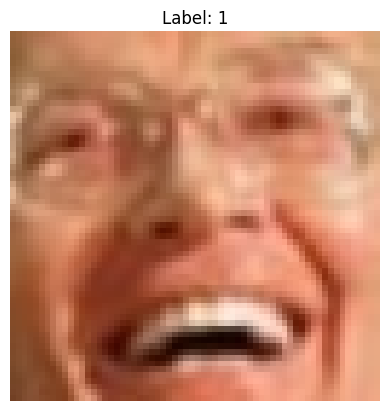

In [ ]:
images, labels = next(iter(train_loader))

img = images[4]
label = labels[0]

# desnormalizar [-1,1] → [0,1]
img = img * 0.5 + 0.5
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

# AUTOENCODER

## Definición del modelo

In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        # Downsampling mientras se incrementa la profundidad
        # Input: imágenes RGB normalizadas para [-1,1]
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),  # (3, 64, 64) -> (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (64, 32, 32) -> (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Decoder
        # Upsampling que dobla la resolución
        # Input: imágenes comprimidas
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # (128, 16, 16) -> (128, 32, 32)
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), # (128, 32, 32) -> (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'), # (64, 32, 32) -> (64, 64, 64)
        )

        # Final layer to get back to original image
        self.final_layer = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),  # (64, 64, 64) -> (3, 64, 64)
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        output = self.final_layer(decoded)
        return output

## Entrenamiento del modelo

In [ ]:
def train_autoencoder(autoencoder, train_loader, val_loader, optimizer, criterion, device, epochs=30, lr=0.001):
    # Move model to GPU if available
    autoencoder = autoencoder.to(device)

    # Training loop
    train_losses = []
    val_losses = []

    # Guarda la hora en la que empezó la ejecución del entrenamiento
    start_time = time.time()

    for epoch in tqdm(range(epochs), desc="AUTOENCODER Training Progress"):
        # %%%%% ENTRENAMIENTO %%%%%
        autoencoder.train()
        train_loss = 0

        for inputs, _ in train_loader:
            inputs = inputs.to(device) # batch data

            optimizer.zero_grad()

            outputs = autoencoder(inputs)

            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()

            # Pérdida por batch
            train_loss += loss.item()

        train_loss /= len(train_loader) # Pérdida promedio por época
        train_losses.append(train_loss) # Se guardan para graficar

        # %%%%% VALIDACIÓN %%%%%
        autoencoder.eval()
        val_loss = 0

        with torch.no_grad():
            for inputs, _ in val_loader:
                inputs = inputs.to(device)

                outputs = autoencoder(inputs)
                loss = criterion(outputs, inputs)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader) # Pérdida promedio por época
        val_losses.append(val_loss) # Se guardan para graficar

        print(f"Epoch [{epoch+1}/{epochs}] |"
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    training_time = time.time() - start_time

    return {"train_losses": train_losses,
            "val_losses": val_losses,
            "training_time": training_time}

In [ ]:
def plot_training_history(train_losses, val_losses, title = "Losses", y_name = "Loss"):
    """Plot training and validation loss history."""
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.title(title)
    plt.ylabel(y_name)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


def visualize_results(autoencoder, x_test, n=10):
    """Visualize original and reconstructed images."""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    autoencoder.eval()

    with torch.no_grad():
        decoded_imgs = autoencoder(x_test)

    # Convert to numpy for plotting
    x_test_np = x_test.cpu().numpy()            # (N, 3, 64, 64)
    decoded_imgs_np = decoded_imgs.cpu().numpy()

    # Plot the results
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test_np[i][0], cmap='gray')        # ✔️ un canal
        ax.set_axis_off()

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs_np[i][0], cmap='gray') # ✔️ un canal
        ax.set_axis_off()

    plt.show()

## Instanciación del método

AUTOENCODER Training Progress:   3%|▎         | 1/30 [05:22<2:35:38, 322.01s/it]

Epoch [1/30] |Train Loss: 0.1802, Val Loss: 0.1444


AUTOENCODER Training Progress:   7%|▋         | 2/30 [05:24<1:02:32, 134.01s/it]

Epoch [2/30] |Train Loss: 0.1054, Val Loss: 0.1002


AUTOENCODER Training Progress:  10%|█         | 3/30 [05:26<33:16, 73.95s/it]   

...

Epoch [28/30] |Train Loss: 0.0355, Val Loss: 0.0334


AUTOENCODER Training Progress:  97%|█████████▋| 29/30 [06:32<00:02,  2.48s/it]

Epoch [29/30] |Train Loss: 0.0345, Val Loss: 0.0327


AUTOENCODER Training Progress: 100%|██████████| 30/30 [06:34<00:00, 13.16s/it]

Epoch [30/30] |Train Loss: 0.0340, Val Loss: 0.0324


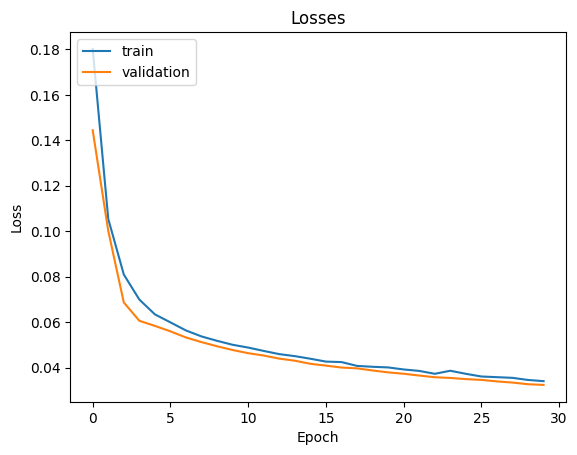

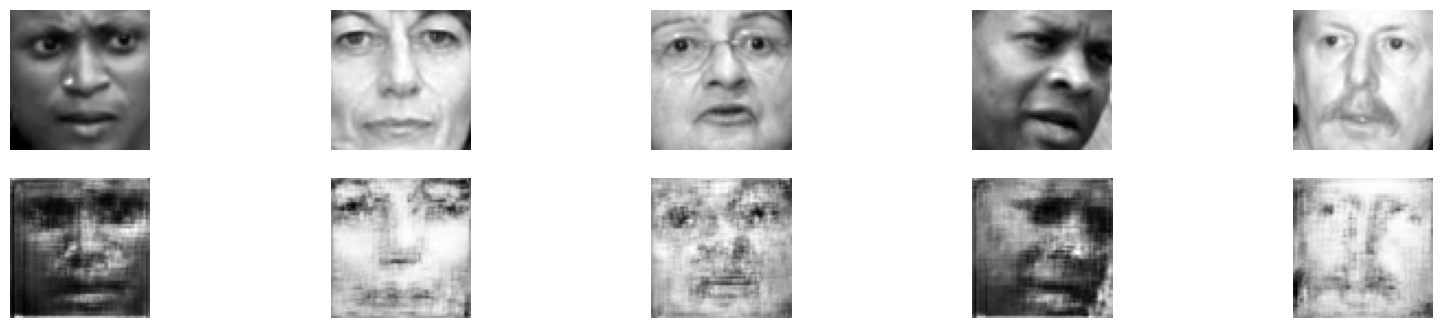

394.71429777145386


In [ ]:
# Initialize model
autoencoder = ConvAutoencoder()

epochs = 30
learning_rate = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define optimizer and loss function
optimizer = optim.SGD(autoencoder.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Train the model
AEmetrics = train_autoencoder(autoencoder, train_loader, val_loader, optimizer, criterion, device=device, epochs=epochs, lr=learning_rate)

# Plot training history
plot_training_history(AEmetrics["train_losses"],AEmetrics["val_losses"])

# Visualize results
images, _ = next(iter(test_loader))
images = images.to(device)
visualize_results(autoencoder, images, n=5)

print(AEmetrics["training_time"])

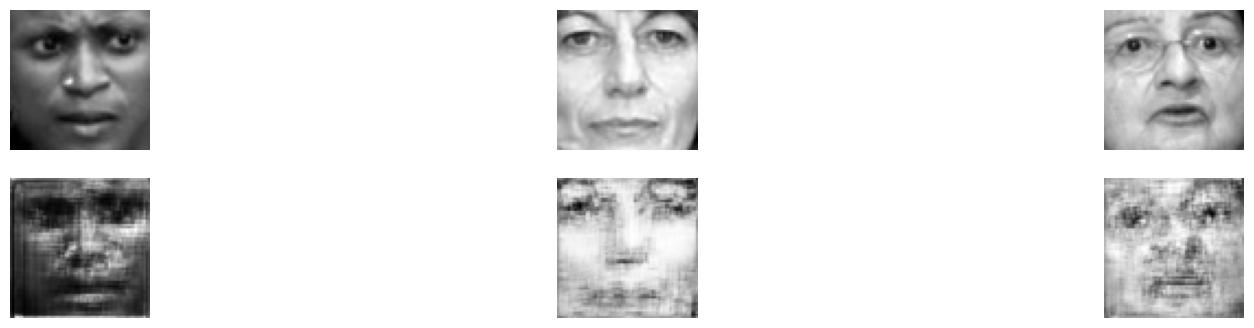

In [ ]:
# Visualize results
images, _ = next(iter(test_loader))
images = images.to(device)
visualize_results(autoencoder, images, n=15)

## Evaluación del modelo con ROC

https://pmc.ncbi.nlm.nih.gov/articles/PMC2749250/#:~:text=El%20%C3%ADndice%20de%20Youden%20se,para%20el%20biomarcador%20de%20inter%C3%A9s.

Como el autoencoder no ejecuta clasificación directamente, decidimos un umbral para el error de reconstrucción utilizando el índice Youden, punto de equilibrio entre la specificity y la sensitivity del modelo, que es en el ROC la distancia vertical máxima. El AUC indica separación significativa entre clases.

AUC (Autoencoder, TEST): 0.579


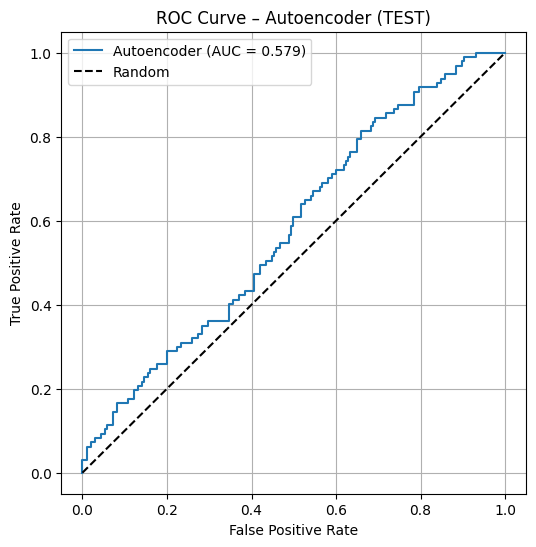

Chosen threshold (AE): 0.025163


In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score
autoencoder.eval()

errors = []
labels = []

with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)

        recon = autoencoder(images)

        # Error de reconstrucción POR IMAGEN
        batch_errors = torch.mean((images - recon) ** 2, dim=(1,2,3))

        errors.extend(batch_errors.cpu().numpy())
        labels.extend(lbls.numpy())

errors = np.array(errors)
labels = np.array(labels)

# ROC y AUC
fpr, tpr, thresholds = roc_curve(labels, errors)
roc_auc = auc(fpr, tpr)

print(f"AUC (Autoencoder, TEST): {roc_auc:.3f}")

# Gráfica ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Autoencoder (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Autoencoder (TEST)")
plt.legend()
plt.grid(True)
plt.show()

# Umbral óptimo (Youden J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
threshold = thresholds[best_idx]

print(f"Chosen threshold (AE): {threshold:.6f}")

## Predicción de etiquetas

In [ ]:
y_pred_ae = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        recon = autoencoder(images)
        batch_errors = torch.mean((images - recon) ** 2, dim=(1,2,3))

        preds = (batch_errors > threshold).int()
        y_pred_ae.append(preds.cpu())

y_pred_ae = torch.cat(y_pred_ae).numpy()

# CNN

## Definición del modelo

In [ ]:
class LeNet5_Modern(nn.Module):
  def __init__(self, num_classes=2):
    super().__init__()

    # CAPA 1: 3×64×64 -> 6×60×60
    self.conv1 = nn.Conv2d(3,6,5)
    self.bn1 = nn.BatchNorm2d(6)

    # CAPA 2: 6×30×30 ->  16×26×26
    self.conv2 = nn.Conv2d(6,16,5)
    self.bn2 = nn.BatchNorm2d(16)

    # CAPA 3: 16 -> 120x13x13
    self.conv3 = nn.Conv2d(16,120,5,padding=2)
    self.bn3 = nn.BatchNorm2d(120)

    # CAPA PRE-FULLY CONNECTED: POOLING PROGRESIVO
    # 13×13 -> 6×6 -> 3×3 -> 1×1
    self.pool1 = nn.AvgPool2d(2)
    self.pool2 = nn.AvgPool2d(2)
    self.pool3 = nn.AvgPool2d(3)

    # FULLY CONNECTED
    self.fc1 = nn.Linear(120,84)
    self.fc2 = nn.Linear(84,num_classes)

  def forward(self, x):
    # Capa 1
    x = self.conv1(x)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.avg_pool2d(x,2,2)

    # Capa 2:
    x = self.conv2(x)
    x = self.bn2(x)
    x = F.relu(x)
    x = F.avg_pool2d(x,2,2)

    # Capa 3:
    x = self.conv3(x)
    x = F.relu(x)

    # Agregación espacial progresiva
    x = self.pool1(x) # 120×6×6
    x= self.pool2(x)  # 120×3×3
    x = self.pool3(x) # 120×1×1

    # Fully-connected
    # Flatten
    x = x.view(x.size(0), -1)

    # Capa 4: activación para la sexta capa de longitud 120 a 84
    x = self.fc1(x)
    x = F.relu(x)
    # Capa final
    x = self.fc2(x)

    return x

## Entrenamiento del modelo

In [ ]:
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs, num_epochs):
    # model = model.to(device)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    start_time = time.time()

    for epoch in tqdm(range(epochs), desc="CNN Training Progress"):
      # ===== TRAINING =====
      model.train()
      train_loss = 0.0
      correct_train = 0
      total_train = 0

      for inputs, labels in train_loader:
          # inputs = inputs.to(device)
          # labels = labels.to(device)

          optimizer.zero_grad()
          outputs = CNN(inputs)

          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          train_loss += loss.item()
          _, predicted = torch.max(outputs, 1)
          total_train += labels.size(0)
          correct_train += (predicted == labels).sum().item()

      train_loss /= len(train_loader)
      train_acc = 100 * correct_train / total_train

      train_losses.append(train_loss)
      train_accs.append(train_acc)

      # ===== VALIDATION =====
      model.eval()
      val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():
          for inputs, labels in val_loader:
              # inputs = inputs.to(device)
              # labels = labels.to(device)

              outputs = model(inputs)
              loss = criterion(outputs, labels)

              val_loss += loss.item()

              _, predicted = torch.max(outputs, 1)
              total_val += labels.size(0)
              correct_val += (predicted == labels).sum().item()

      val_loss /= len(val_loader)
      val_acc = 100 * correct_val / total_val

      val_losses.append(val_loss)
      val_accs.append(val_acc)

      print(f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    training_time = time.time() - start_time

    return {
          "train_losses": train_losses,
          "val_losses": val_losses,
          "train_accs": train_accs,
          "val_accs": val_accs,
          "training_time": training_time
      }

## Instanciación del modelo

CNN Training Progress:   3%|▎         | 1/30 [00:04<01:58,  4.09s/it]

Epoch [1/30] Train Loss: 0.6913, Train Acc: 51.25% | Val Loss: 0.6960, Val Acc: 39.20%


CNN Training Progress:   7%|▋         | 2/30 [00:08<02:02,  4.37s/it]

Epoch [2/30] Train Loss: 0.6916, Train Acc: 51.75% | Val Loss: 0.6915, Val Acc: 52.49%


CNN Training Progress:  10%|█         | 3/30 [00:12<01:52,  4.18s/it]

...

Epoch [28/30] Train Loss: 0.2967, Train Acc: 90.75% | Val Loss: 0.4117, Val Acc: 81.73%


CNN Training Progress:  97%|█████████▋| 29/30 [02:06<00:04,  4.26s/it]

Epoch [29/30] Train Loss: 0.3267, Train Acc: 88.00% | Val Loss: 0.3160, Val Acc: 89.04%


CNN Training Progress: 100%|██████████| 30/30 [02:11<00:00,  4.38s/it]

Epoch [30/30] Train Loss: 0.3950, Train Acc: 83.75% | Val Loss: 0.3703, Val Acc: 84.05%


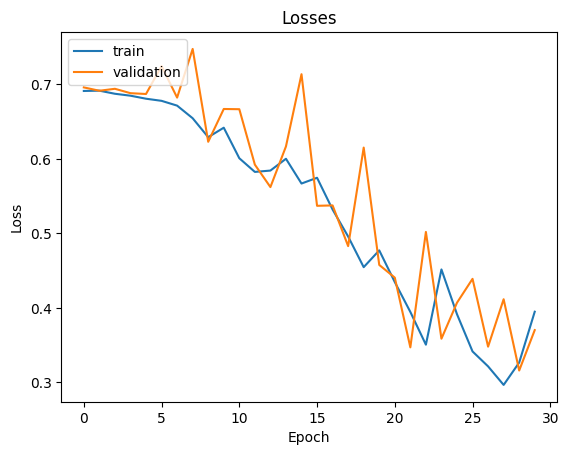

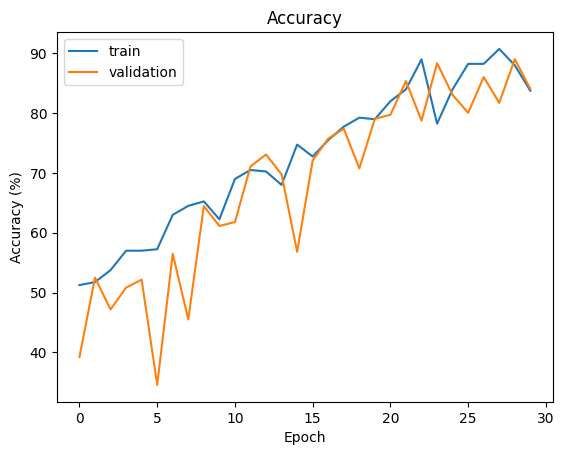

In [ ]:
# Initialize model
CNN = LeNet5_Modern()

# Define optimizer and loss function
epochs = 30
learning_rate = 0.001
optimizer = torch.optim.Adam(CNN.parameters(), lr=learning_rate, weight_decay=0.06)
criterion = nn.CrossEntropyLoss()

# Train the model
CNNmetrics = train_cnn(CNN, train_loader, val_loader, criterion, optimizer, epochs, num_epochs=epochs)
# Plot training history
plot_training_history(CNNmetrics["train_losses"],CNNmetrics["val_losses"])
plot_training_history(CNNmetrics["train_accs"],CNNmetrics["val_accs"], title='Accuracy', y_name='Accuracy (%)')

## Evaluación del modelo

In [ ]:
CNN.eval()
current_loss,correct,total = 0.0, 0, 0
y_pred_cnn = []

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = CNN(images)
        loss = criterion(outputs, labels)

        current_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        y_pred_cnn.append(predicted)

y_pred_cnn = torch.cat(y_pred_cnn).cpu().numpy()

# Modelo ML: SVM

In [ ]:
import numpy as np
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.color import rgb2gray

## Tensor a HOG

1.   Pasamos de (3,64,64) a (64,64,3)
2.   Convertimos a escala de grises
3.   Extracción del HOG

https://www.geeksforgeeks.org/machine-learning/hog-feature-visualization-in-python-using-skimage/

In [ ]:
def tensor_to_hog(tensor_img,orientations=9,pixels_per_cell=(8, 8),cells_per_block=(2, 2),visualize=True):
    image = tensor_img.numpy()

    # [3, H, W] -> [H, W, 3]
    image = np.transpose(image, (1, 2, 0))

    # RGB -> grayscale (promedio simple)
    image_gray = rgb2gray(image)

    # HOG
    features, hog_image = hog(image_gray,orientations=orientations,pixels_per_cell=pixels_per_cell,cells_per_block=cells_per_block,visualize=True,feature_vector=True)
    return features, hog_image, image_gray

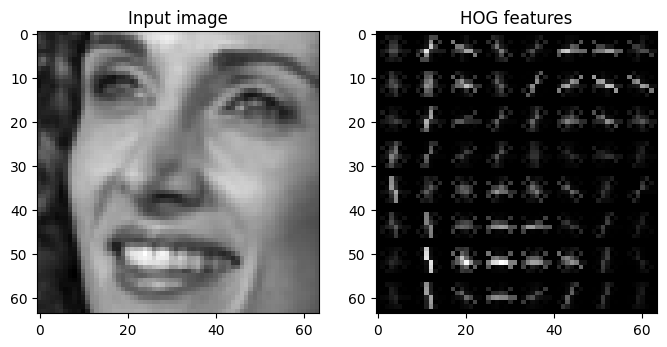

1764


In [ ]:
# Tomar un batch
images, labels = next(iter(train_loader))

# Tomar una imagen
img = images[4]

start_time = time.time()

# HOG con visualización
features, hog_image, image_gray = tensor_to_hog(img, visualize=True)

# Visualizar
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Input image')

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap='gray')
plt.title('HOG features')
plt.show()

print(len(features))

In [ ]:
print(labels[1])

tensor(0)


## Datos para entrenamiento

In [ ]:
def data_extractor(loader):
  X = []
  y = []

  # images es un batch, el primer loop itera sobre batches
  for images, labels in loader:
    # el segundo loop unzipea cada batch en iterables
      for img, label in zip(images, labels):
          features, _, _ = tensor_to_hog(img)
          X.append(features)
          y.append(label.item())

  return np.array(X), np.array(y)

In [ ]:
X_train, y_train = data_extractor(train_loader)
X_val, y_val = data_extractor(val_loader)
X_test, y_test = data_extractor(test_loader)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(400, 1764) (400,)
(301, 1764) (301,)
(302, 1764) (302,)


In [ ]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_val_scaled = sc.transform(X_val)
X_test_scaled = sc.transform(X_test)

## PCA

https://builtin.com/machine-learning/pca-in-python

In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)

(400, 248)


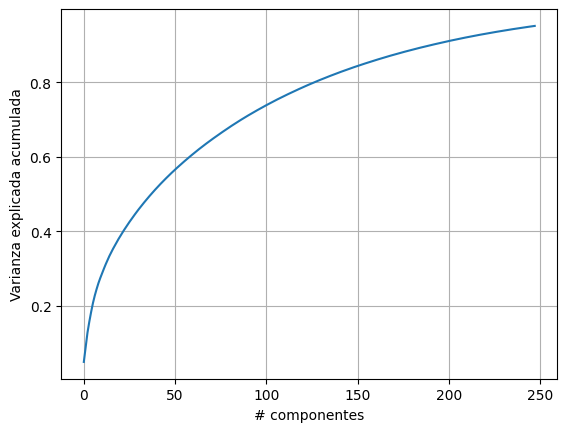

In [ ]:
var_exp = np.cumsum(pca.explained_variance_ratio_)

plt.plot(var_exp)
plt.xlabel("# componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

## Entrenamiento del modelo

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
svm_classifier = SVC(kernel='linear', C=1.0)
svm_classifier.fit(X_train_pca, y_train)

svm_training_time = time.time() - start_time
svm_training_time

246.20794224739075

## Evaluación del modelo

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred_svm = svm_classifier.predict(X_test_pca)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(classification_report(y_test, y_pred_svm, target_names=('0','1')))

cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       205
           1       0.86      0.94      0.90        97

    accuracy                           0.93       302
   macro avg       0.91      0.93      0.92       302
weighted avg       0.93      0.93      0.93       302

[[190  15]
 [  6  91]]


# Accuracy

In [ ]:
preds = {
    "ae": y_pred_ae,
    "cnn": y_pred_cnn,
    "svm": y_pred_svm
}

acc = {}

for name, y_pred in preds.items():
    correct = (y_pred == y_test).sum()
    acc[name] = correct / len(y_test)

In [ ]:
# imprimir el accuracy de cada modelo
print("Accuracy por modelo")
print("---------------------------")
print(f"CNN           : {acc["cnn"]}")
print(f"Autoencoder   : {acc["ae"]}")
print(f"SVM           : {acc["svm"]}")

Accuracy por modelo
---------------------------
CNN           : 0.8774834437086093
Autoencoder   : 0.4900662251655629
SVM           : 0.9304635761589404


# Comparación de etiquetado con ejemplo

In [ ]:
idx = 11

print("Comparación por índice", idx)
print("---------------------------")
print(f"Etiqueta real : {y_test[idx]}")
print(f"CNN           : {y_pred_cnn[idx]}")
print(f"Autoencoder   : {y_pred_ae[idx]}")
print(f"SVM           : {y_pred_svm[idx]}")

Comparación por índice 11
---------------------------
Etiqueta real : 1
CNN           : 1
Autoencoder   : 1
SVM           : 1


# Conteo de parámetros

Número de pesos y sesgos que el modelo aprende durante el entrenamiento

https://www.ibm.com/mx-es/think/topics/model-parameters

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
cnn_params = count_parameters(CNN)
ae_params  = count_parameters(autoencoder)

print(f"CNN parameters        : {cnn_params}")
print(f"Autoencoder parameters: {ae_params}")

CNN parameters        : 61610
Autoencoder parameters: 151683


En un SVM lineal,

$$f(x)=w^T x+b$$

*   $w\in\mathbb{R}\rightarrow d \text{ pesos}$
*   $b\in\mathbb{R}\rightarrow 1 \text{ bias}$

$\text{#params}=d+1$



In [ ]:
# w tiene shape (n_classes, d) en multiclase
w = svm_classifier.coef_
b = svm_classifier.intercept_

svm_params = w.size + b.size

print("SVM (linear) number of parameters:", svm_params)

SVM (linear) number of parameters: 249


CNN / Autoencoder:
El número de parámetros corresponde al total de pesos y sesgos entrenables del modelo.

SVM lineal:
El clasificador está completamente definido por un vector de pesos de dimensión d y un término de sesgo, por lo que el número de parámetros es d+1, donde d es la dimensión del espacio de características tras PCA.

# Tiempo de entrenamiento

In [ ]:
# imprimir el training time de cada modelo
print("Tiempo de entrenamiento por modelo")
print("---------------------------")
print(f"CNN           : {CNNmetrics['training_time']}")
print(f"Autoencoder   : {AEmetrics['training_time']}")
print(f"SVM           : {svm_training_time}")

Tiempo de entrenamiento por modelo
---------------------------
CNN           : 73.59401249885559
Autoencoder   : 394.71429777145386
SVM           : 0.016244173049926758


# Tiempo de inferencia

Inference time = cuánto se tarda el modelo en dar una respuesta una vez que ya está entrenado.

Tiempo que tarda el modelo en dar una respuesta una vez que ya está entrenado.

En la práctica el modelo se usa así:
una imagen → una decisión → rápido

Se mide como la media y desviación est. de la ejecución de un mismo sample por el forward (predicción) 100 veces.

## CNN

In [ ]:
CNN.eval()

# una sola imagen
img, _ = test_dataset[0]
img = img.unsqueeze(0).to(device)

times = []

with torch.no_grad():
    for _ in range(100):
        start = time.perf_counter() # performance counter, usado para benchmarking por su alta resolución y accuracy
        _ = CNN(img)
        end = time.perf_counter()
        times.append(end - start)

times = np.array(times)

print(f"CNN inference time: {times.mean()*1e3:.3f} ± {times.std()*1e3:.3f} ms")


CNN inference time: 0.827 ± 3.360 ms


## Autoencoder

In [ ]:
autoencoder.eval()

img, _ = test_dataset[0]
img = img.unsqueeze(0).to(device)

times = []

with torch.no_grad():
    for _ in range(100):
        start = time.perf_counter() # performance counter, usado para benchmarking por su alta resolución y accuracy
        _ = autoencoder(img)
        end = time.perf_counter()
        times.append(end - start)

times = np.array(times)

print(f"Autoencoder inference time: {times.mean()*1e3:.3f} ± {times.std()*1e3:.3f} ms")

Autoencoder inference time: 0.592 ± 1.046 ms


## SVM

In [ ]:
# una sola muestra
x = X_test_pca[0].reshape(1, -1)

times = []

for _ in range(100):
    start = time.perf_counter() # performance counter, usado para benchmarking por su alta resolución y accuracy
    _ = svm_classifier.predict(x)
    end = time.perf_counter()
    times.append(end-start)

times = np.array(times)

print(f"SVM inference time: {times.mean()*1e3:.3f} ± {times.std()*1e3:.3f} ms")

SVM inference time: 0.422 ± 0.215 ms
